# Project Sentinel:Hazardous Asteroid Prediction AI

#### Machine Learning-Based Hazardous vs Non-Hazardous NEO Classification
#### Presented by: Sonakshi pundir
#### Course: Machine learning Internship

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance
import joblib

RANDOM_STATE = 42
DATA_PATH = Path(r"C:\Users\HP\Downloads\neo (3).csv")

if not DATA_PATH.exists():
    # Helpful fallback for common notebook locations
    candidates = list(Path(".").glob("*.csv"))
    if candidates:
        DATA_PATH = candidates[0]
    else:
        raise FileNotFoundError("Place the supplied NEO CSV file in the same folder as this notebook.")

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

Dataset shape: (90836, 10)


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False
3,3596030,(2012 BV13),0.096506,0.215794,24764.303138,2.543497e+07,Earth,False,22.20,False
4,3667127,(2014 GE35),0.255009,0.570217,42737.733765,4.627557e+07,Earth,False,20.09,True



Data types:


,dtype
id,int64
name,object
est_diameter_min,float64
est_diameter_max,float64
relative_velocity,float64
miss_distance,float64
orbiting_body,object
sentry_object,bool
absolute_magnitude,float64
hazardous,bool


In [2]:
# Basic data-quality checks
print("Missing values:")
display(df.isna().sum().to_frame("missing_values"))

print("Duplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["hazardous"].value_counts().rename(index={False:"Non-Hazardous", True:"Hazardous"}).to_frame("count"))

print("\nTarget percentage:")
display((df["hazardous"].value_counts(normalize=True) * 100)
        .rename(index={False:"Non-Hazardous", True:"Hazardous"})
        .round(2).to_frame("percentage"))


Missing values:


,missing_values
id,0
name,0
est_diameter_min,0
est_diameter_max,0
relative_velocity,0
miss_distance,0
orbiting_body,0
sentry_object,0
absolute_magnitude,0
hazardous,0


Duplicate rows: 0

Target distribution:


,count
hazardous,
Non-Hazardous,81996
Hazardous,8840



Target percentage:


,percentage
hazardous,
Non-Hazardous,90.27
Hazardous,9.73


In [3]:
# Remove duplicate rows if any
df = df.drop_duplicates().copy()

# Target conversion
df["hazardous"] = df["hazardous"].astype(int)

# Relevant raw predictors available in the supplied CSV
raw_features = [
    "est_diameter_min",
    "est_diameter_max",
    "relative_velocity",
    "miss_distance",
    "absolute_magnitude"
]

X_raw = df[raw_features].copy()
y = df["hazardous"].copy()

print("Cleaned dataset shape:", df.shape)
display(X_raw.describe().T)

Cleaned dataset shape: (90836, 10)


,count,mean,std,min,25%,50%,75%,max
est_diameter_min,90836.0,1.274321e-01,2.985112e-01,0.000609,1.925551e-02,4.836765e-02,1.434019e-01,3.789265e+01
est_diameter_max,90836.0,2.849469e-01,6.674914e-01,0.001362,4.305662e-02,1.081534e-01,3.206564e-01,8.473054e+01
relative_velocity,90836.0,4.806692e+04,2.529330e+04,203.346433,2.861902e+04,4.419012e+04,6.292360e+04,2.369901e+05
miss_distance,90836.0,3.706655e+07,2.235204e+07,6745.532516,1.721082e+07,3.784658e+07,5.654900e+07,7.479865e+07
absolute_magnitude,90836.0,2.352710e+01,2.894086e+00,9.230000,2.134000e+01,2.370000e+01,2.570000e+01,3.320000e+01


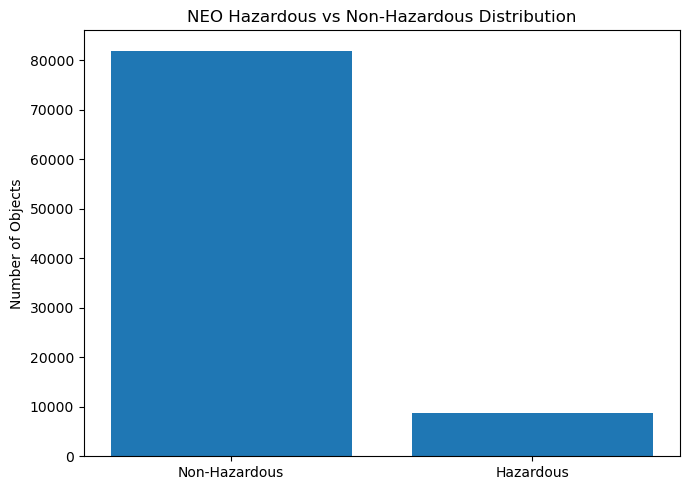

Hazardous objects: 8,840 (9.73%)
Non-hazardous objects: 81,996 (90.27%)


In [4]:
# Class distribution
counts = y.value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Non-Hazardous", "Hazardous"], [counts.get(0, 0), counts.get(1, 0)])
plt.title("NEO Hazardous vs Non-Hazardous Distribution")
plt.ylabel("Number of Objects")
plt.tight_layout()
plt.show()

print(f"Hazardous objects: {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"Non-hazardous objects: {(1-y).sum():,} ({(1-y.mean())*100:.2f}%)")

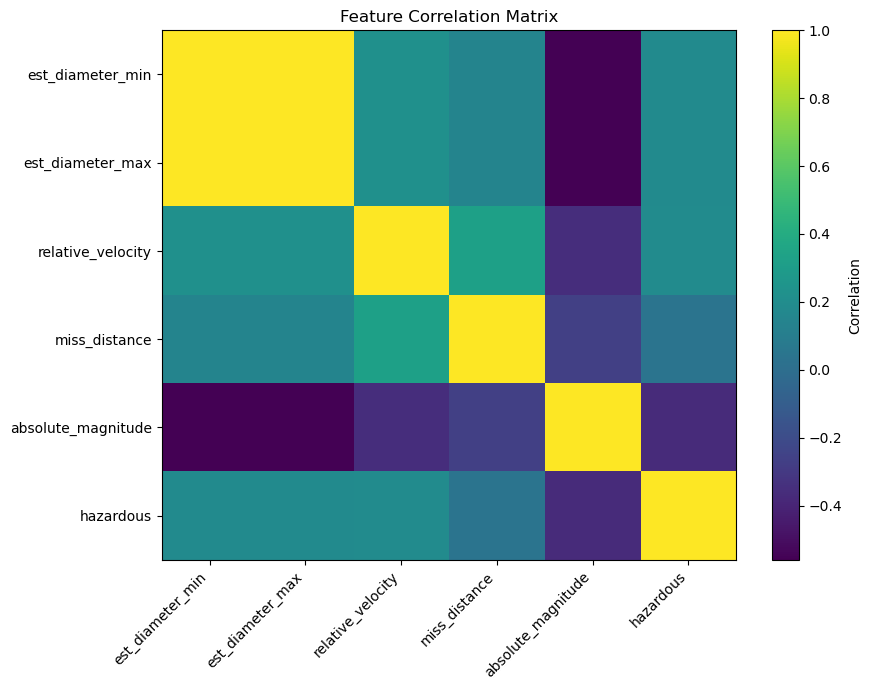

,correlation_with_hazardous
hazardous,1.000000
relative_velocity,0.191185
est_diameter_max,0.183363
est_diameter_min,0.183363
miss_distance,0.042302
absolute_magnitude,-0.365267


In [5]:
# Correlation matrix
corr = pd.concat([X_raw, y.rename("hazardous")], axis=1).corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr, interpolation="nearest", aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label="Correlation")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

display(corr["hazardous"].sort_values(ascending=False).to_frame("correlation_with_hazardous"))

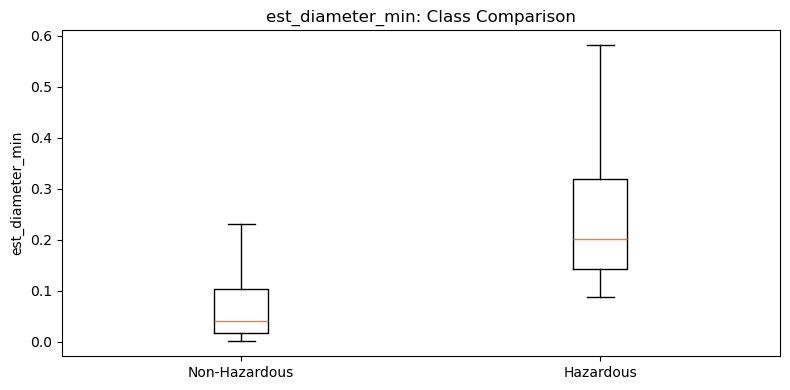

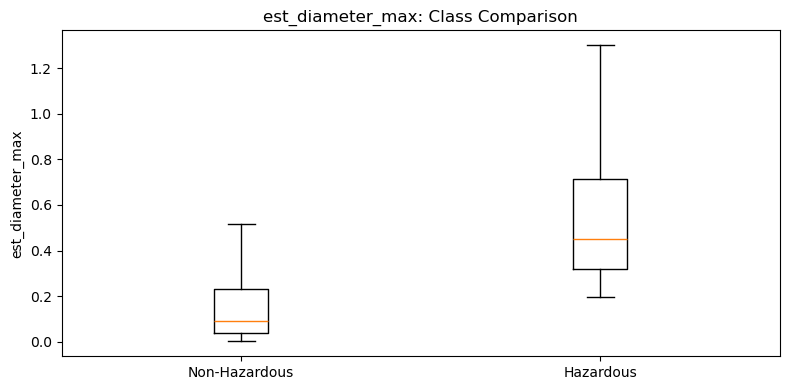

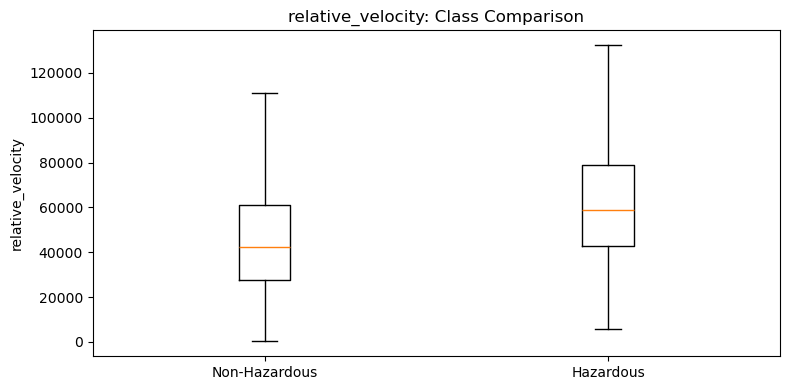

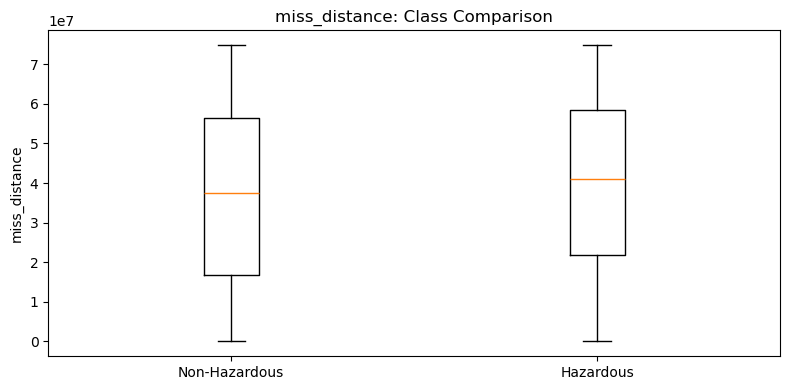

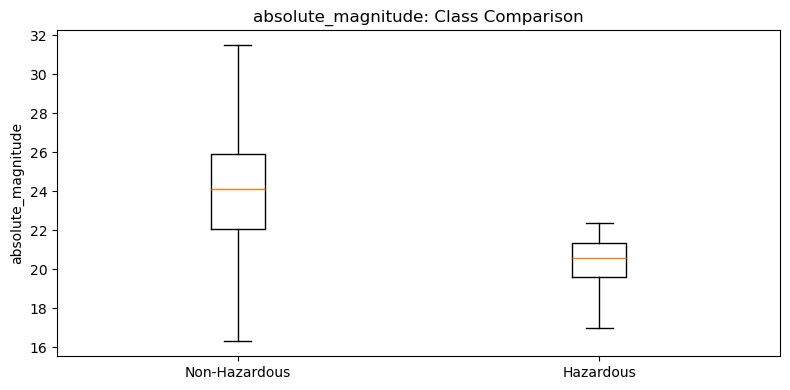

In [6]:
# Compare feature distributions by class using boxplots
for feature in raw_features:
    plt.figure(figsize=(8, 4))
    plt.boxplot(
        [X_raw.loc[y == 0, feature].dropna(),
         X_raw.loc[y == 1, feature].dropna()],
        tick_labels=["Non-Hazardous", "Hazardous"],
        showfliers=False
    )
    plt.title(f"{feature}: Class Comparison")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

In [7]:
def engineer_features(data):
    out = data[raw_features].copy()

    out["mean_diameter"] = (
        out["est_diameter_min"] + out["est_diameter_max"]
    ) / 2

    out["diameter_range"] = (
        out["est_diameter_max"] - out["est_diameter_min"]
    )

    out["velocity_distance_ratio"] = (
        out["relative_velocity"] / out["miss_distance"].replace(0, np.nan)
    )

    out["log_miss_distance"] = np.log1p(out["miss_distance"])

    return out

X = engineer_features(df)

print("Final feature matrix:", X.shape)
display(X.head())

Final feature matrix: (90836, 9)


,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,mean_diameter,diameter_range,velocity_distance_ratio,log_miss_distance
0,1.198271,2.679415,13569.249224,5.483974e+07,16.73,1.938843,1.481144,0.000247,17.819926
1,0.265800,0.594347,73588.726663,6.143813e+07,20.00,0.430073,0.328547,0.001198,17.933541
2,0.722030,1.614507,114258.692129,4.979872e+07,17.83,1.168268,0.892478,0.002294,17.723500
3,0.096506,0.215794,24764.303138,2.543497e+07,22.20,0.156150,0.119288,0.000974,17.051636
4,0.255009,0.570217,42737.733765,4.627557e+07,20.09,0.412613,0.315208,0.000924,17.650125


In [8]:
# Check correlations after feature engineering
engineered_corr = pd.concat([X, y.rename("hazardous")], axis=1).corr(numeric_only=True)["hazardous"]
display(engineered_corr.sort_values(ascending=False).to_frame("correlation_with_hazardous"))

,correlation_with_hazardous
hazardous,1.000000
relative_velocity,0.191185
diameter_range,0.183363
est_diameter_max,0.183363
mean_diameter,0.183363
est_diameter_min,0.183363
log_miss_distance,0.065065
miss_distance,0.042302
velocity_distance_ratio,-0.019218
absolute_magnitude,-0.365267


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Training hazardous rate:", y_train.mean())
print("Testing hazardous rate:", y_test.mean())

Training samples: 72668
Testing samples: 18168
Training hazardous rate: 0.09731931524192217
Testing hazardous rate: 0.09731395860854249


In [10]:
# Logistic Regression pipeline: imputation + scaling + balanced classifier
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

# Random Forest pipeline: imputation + balanced non-linear classifier
rf_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("classifier", RandomForestClassifier(
        n_estimators=250,
        max_depth=18,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

models = {
    "Logistic Regression": logistic_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob),
        "PR-AUC": average_precision_score(y_test, prob)
    })

results_df = pd.DataFrame(results).sort_values(
    ["F1", "PR-AUC"], ascending=False
).reset_index(drop=True)

display(results_df.style.format("{:.4f}", subset=results_df.columns[1:]))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Random Forest,0.8255,0.3478,0.9061,0.5027,0.9205,0.5288
1,Logistic Regression,0.7868,0.3046,0.9287,0.4588,0.8813,0.3443


In [11]:
# Select the model with the strongest F1 score, then PR-AUC
best_name = results_df.iloc[0]["Model"]
best_model = models[best_name]

best_pred = best_model.predict(X_test)
best_prob = best_model.predict_proba(X_test)[:, 1]

print("Selected final model:", best_name)
print("\nClassification Report:")
print(classification_report(
    y_test,
    best_pred,
    target_names=["Non-Hazardous", "Hazardous"],
    digits=4
))

Selected final model: Random Forest

Classification Report:
               precision    recall  f1-score   support

Non-Hazardous     0.9878    0.8168    0.8942     16400
    Hazardous     0.3478    0.9061    0.5027      1768

     accuracy                         0.8255     18168
    macro avg     0.6678    0.8615    0.6984     18168
 weighted avg     0.9255    0.8255    0.8561     18168



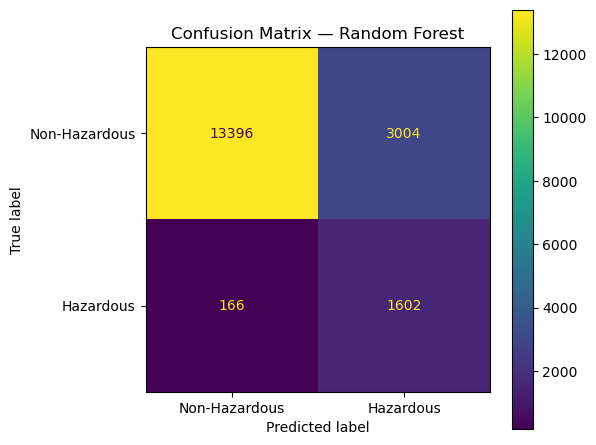

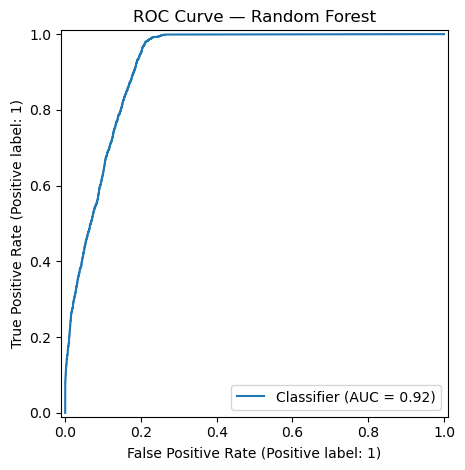

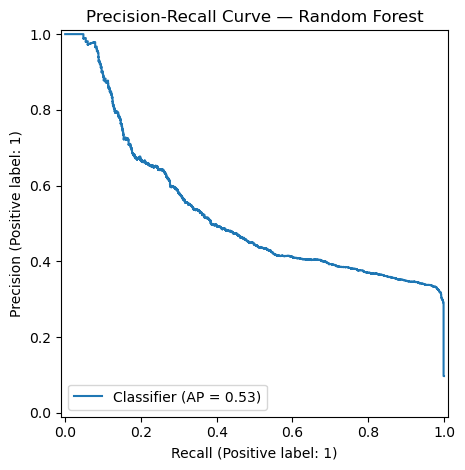

In [12]:
# Confusion matrix
cm = confusion_matrix(y_test, best_pred)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Hazardous", "Hazardous"]
).plot(ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

# ROC curve
RocCurveDisplay.from_predictions(y_test, best_prob)
plt.title(f"ROC Curve — {best_name}")
plt.tight_layout()
plt.show()

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, best_prob)
plt.title(f"Precision-Recall Curve — {best_name}")
plt.tight_layout()
plt.show()


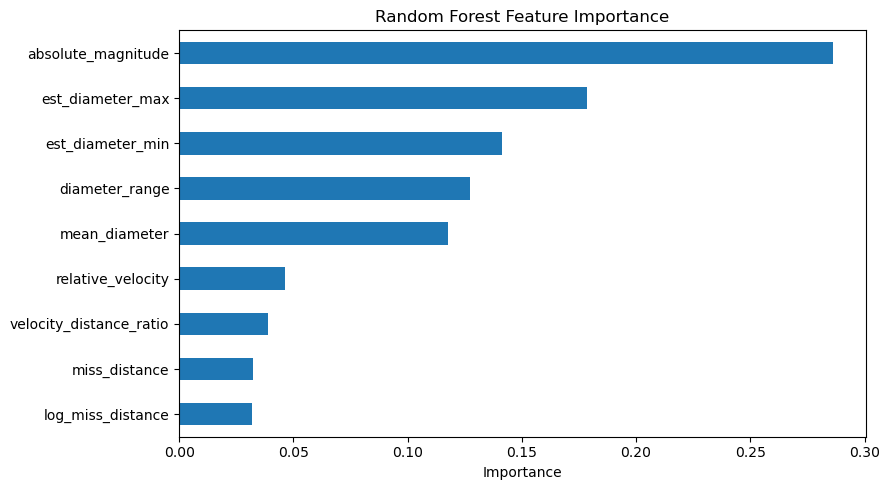

,importance
absolute_magnitude,0.286316
est_diameter_max,0.178441
est_diameter_min,0.141242
diameter_range,0.127504
mean_diameter,0.117715
relative_velocity,0.046175
velocity_distance_ratio,0.038712
miss_distance,0.032173
log_miss_distance,0.031722


In [13]:
# Feature importance / explainability
if best_name == "Random Forest":
    fitted_rf = best_model.named_steps["classifier"]
    importance = pd.Series(
        fitted_rf.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(9, 5))
    importance.sort_values().plot(kind="barh")
    plt.title("Random Forest Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    display(importance.to_frame("importance"))
else:
    # Coefficient-based explanation for Logistic Regression
    coef = pd.Series(
        np.abs(best_model.named_steps["classifier"].coef_[0]),
        index=X.columns
    ).sort_values(ascending=False)

    plt.figure(figsize=(9, 5))
    coef.sort_values().plot(kind="barh")
    plt.title("Logistic Regression Absolute Coefficient Importance")
    plt.xlabel("Absolute coefficient")
    plt.tight_layout()
    plt.show()

    display(coef.to_frame("absolute_coefficient"))

In [14]:
# Save the complete final pipeline
MODEL_PATH = Path("hazardous_asteroid_model.joblib")
joblib.dump(best_model, MODEL_PATH)

print("Saved model to:", MODEL_PATH.resolve())

Saved model to: C:\Users\Asus\ISTUDIO PROJECT\hazardous_asteroid_model.joblib


In [15]:
def predict_asteroid(
    est_diameter_min,
    est_diameter_max,
    relative_velocity,
    miss_distance,
    absolute_magnitude
):
    """Predict whether one NEO is Hazardous or Non-Hazardous."""
    sample = pd.DataFrame([{
        "est_diameter_min": est_diameter_min,
        "est_diameter_max": est_diameter_max,
        "relative_velocity": relative_velocity,
        "miss_distance": miss_distance,
        "absolute_magnitude": absolute_magnitude
    }])

    sample_features = engineer_features(sample)
    probability = best_model.predict_proba(sample_features)[0, 1]
    prediction = int(probability >= 0.5)

    label = "Hazardous" if prediction else "Non-Hazardous"

    return {
        "prediction": label,
        "hazard_probability": round(float(probability), 4)
    }

# Example prediction using one held-out test object
example = X_test.iloc[[0]]
example_original = df.loc[example.index, raw_features].iloc[0]

print("Example input:")
display(example_original.to_frame("value"))

print("Prediction:")
print(predict_asteroid(
    example_original["est_diameter_min"],
    example_original["est_diameter_max"],
    example_original["relative_velocity"],
    example_original["miss_distance"],
    example_original["absolute_magnitude"]
))

Example input:


,value
est_diameter_min,4.726667e-01
est_diameter_max,1.056915e+00
relative_velocity,2.177924e+04
miss_distance,3.443050e+07
absolute_magnitude,1.875000e+01


Prediction:
{'prediction': 'Non-Hazardous', 'hazard_probability': 0.2503}


In [16]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

# 2. LOAD DATASET

df = pd.read_csv("C:/Users/Asus/ISTUDIO PROJECT/neo (3).csv")

X_raw = df.copy()


# 3. CHECK REQUIRED COLUMNS

required_columns = [
    "est_diameter_min",
    "est_diameter_max",
    "relative_velocity"
]

missing_columns = [
    col for col in required_columns
    if col not in X_raw.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns: {missing_columns}\n"
        f"Available columns are: {list(X_raw.columns)}"
    )


# 4. REMOVE MISSING VALUES FOR MEDIAN CALCULATION


for col in required_columns:
    X_raw[col] = pd.to_numeric(X_raw[col], errors="coerce")


# 5. CREATE WIDGETS

w_min = widgets.FloatText(
    value=float(X_raw["est_diameter_min"].median()),
    description="Min Diameter:",
    style={"description_width": "initial"}
)

w_max = widgets.FloatText(
    value=float(X_raw["est_diameter_max"].median()),
    description="Max Diameter:",
    style={"description_width": "initial"}
)

w_vel = widgets.FloatText(
    value=float(X_raw["relative_velocity"].median()),
    description="Velocity:",
    style={"description_width": "initial"}
)


# 6. OUTPUT AREA

output = widgets.Output()


# 7. FILTER FUNCTION

def apply_filter(change=None):

    with output:
        clear_output(wait=True)

        min_diameter = w_min.value
        max_diameter = w_max.value
        velocity = w_vel.value

        # Make sure the minimum isn't greater than maximum
        if min_diameter > max_diameter:
            print("Error: Min Diameter cannot be greater than Max Diameter.")
            return

        # Filter the original data
        filtered_data = X_raw[
            (X_raw["est_diameter_min"] >= min_diameter) &
            (X_raw["est_diameter_max"] <= max_diameter) &
            (X_raw["relative_velocity"] <= velocity)
        ]

        print(f"Total records: {len(X_raw)}")
        print(f"Filtered records: {len(filtered_data)}")
        print()

        display(filtered_data.head(20))


# 8. BUTTON

apply_button = widgets.Button(
    description="Apply Filter",
    button_style="primary",
    icon="filter"
)

apply_button.on_click(apply_filter)


# 9. DISPLAY WIDGETS

display(
    widgets.VBox([
        w_min,
        w_max,
        w_vel,
        apply_button,
        output
    ])
)


# 10. SHOW INITIAL RESULTS

apply_filter()